# Tutorial 400: ContextFlow — Spatially-Aware Transport on Axolotl Brain Development

In these 2 tutorials (400 & 410), we will be implementing 2 custom coupling methods using SCFlow.


Standard optimal transport couples source and target cells by transcriptomic similarity: we check the gene expression of the these cells. This is a valid approach and one which is used by almost everyone. However **cells do not exist in isolation**. A cell's identity is also shaped by the signalling environment of the cells surrounding it. Two cells with nearly identical expression profiles can have very different paths depending on where they sit in tissue.


***`ContextFlow`*** [Rathod et al., 2024, arXiv:2510.02952](https://arxiv.org/abs/2510.02952) is a framework which utilizes this extra information. The key
observation is that cells with *similar spatial neighbourhoods* should
be matched to one another during transport — because neighbourhood similarity is a
proxy for shared local signalling context and developmental
trajectory. ContextFlow encodes this by augmenting each cell's representation with a
**context vector**: the mean expression of its spatial neighbours & The Ligand-Receptor Activation. The OT cost is then modified so that cells in similar spaces get coupled with one another during matching:

$$C_{i,j} = \alpha \|\mathbf{x}_i - \mathbf{x}_j\|^2 + (1-\alpha)\,M_{i,j}$$

$$M_{i,j} = \lambda\,\|\text{ss}_i - \text{ss}_j\|^2 + (1-\lambda)\,\|\text{lr}_i - \text{lr}_j\|^2$$

where:
- $C_{i,j}$ — modified OT transport cost between source cell $i$ and target cell $j$
- $\mathbf{x}_i, \mathbf{x}_j$ — PCA embeddings of the source and target cells (`X_pca`)
- $M_{i,j}$ — Transitional Plausibility Matrix (TPM): High value = biologically implausible match
- $\text{ss}_i, \text{ss}_j$ — Spatial Smoothness: Mean PCA embedding of each cell's spatial neighbours (`local_mean_X_pca`)
- $\text{lr}_i, \text{lr}_j$ — Ligand-Receptor features: LIANA co-expression feature vector aggregated over the spatial neighbourhood (`LR_pattern`)
- $\alpha \in [0,1]$ — blend between transcriptomic cost and spatial prior ($\alpha=1$: pure transcriptomic OT, $\alpha=0$: pure spatial prior)
- $\lambda \in [0,1]$ — blend between SS and LR within the TPM ($\lambda=1$: pure SS, $\lambda=0$: pure LR)

This is the **CTF-C** (Context-aware Transport via cost Function modification) variant of cost modification which will be implemented here.

## In this tutorial

We apply CTF-C to the **Axolotl Brain** Stereo-seq dataset (Wei et al. 2022,
GSE232025) — one of the three biological benchmarks from the paper. We will implement the two tasks that the authors ran to benchmark `ContextFlow` - `Interpolation` in which the model will predict **stage57 -> juvenile** & `Extrapolation` in which the model will predict **juvenile -> adult**

**Data**: preprocessed `axolotl_processed.h5ad` (28,757 cells, 5 developmental stages).
[Refer to the paper's git repo to know how to download and preprocess the dataset.](https://github.com/santanurathod/ContextFlow/tree/main/datasets)

In [223]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Contents

1. Load and Explore Data
2. Build State-Context Representation3. Subset and Register
4. CTF-C Coupling
5. Model Setup and Training
6. Inference and Evaluation

In [ ]:
import numpy as np
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import functools
import pandas as pd
import ot as pot
import warnings

from sc_flow import SCFlow
from sc_flow.backends.torch.coupling import ot_linear_coupling
from sc_flow.data.samplers._train import MultiTransitionSampler
from sc_flow.backends.torch.metrics import EnergyDistance, MaximumMeanDiscrepancy
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
prng = torch.Generator().manual_seed(SEED)
warnings.filterwarnings("ignore")

## 1. Load and Explore Data

The preprocessed h5ad already contains `X_pca` (50 PCs), `local_mean_X_pca` (SS context),
`LR_pattern` (LIANA LR features), and `X_umap` — all computed previously. We have the data for 5 developmental stages.

**Key `.obs` columns**

| Column | Description |
|---|---|
| `day` | Developmental stage: `Stage44`, `Stage54`, `Stage57`, `Juvenile`, `Adult`. This is the condition key |

**Key `.obsm` entries**

| Key | Shape | Description |
|---|---|---|
| `X_pca` | (n_cells, 50) | 50-component PCA of normalised HVG expression. This is the primary transcriptomic representation used for transport. |
| `local_mean_X_pca` | (n_cells, 50) | Spatial Smoothness (SS) context: mean `X_pca` of each cell's spatial neighbours within radius 50 (Stereo-seq coordinate units).|
| `spatial` | (n_cells, 2) | Raw Stereo-seq (x, y) tissue coordinates. Used to build the SS context and will also be used to visualise spatial expression patterns. |
| `X_umap` | (n_cells, 2) | 2-D UMAP embedding for visualisation only — not used in training. |
| `LR_pattern` | (n_cells, k) | Ligand-receptor co-expression features from LIANA. Available for extended analyses. Used in tutorial 410|

In [ ]:
DATA_PATH = r"400_data\GSE232025_stereoseq_g_10000_nzp_0.1.h5ad"
STAGES_ALL = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]
STAGE_TIMES = {"Stage44": 0, "Stage54": 1, "Stage57": 2, "Juvenile": 3, "Adult": 4}

AnnData object with n_obs × n_vars = 28757 × 10000
    obs: 'CellID', 'Batch', 'cell_id', 'celltype', 'day'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'gene_symbol_original'
    uns: 'LR_pattern_pairs', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'LR_pattern', 'X_pca', 'X_umap', 'local_mean_X_pca', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances', 'spatial_connectivities'


c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
adata = sc.read_h5ad(DATA_PATH)

adata.uns["stage_emb"] = {s: np.array([t], dtype=np.float32) for s, t in STAGE_TIMES.items()}
adata.obs["day"] = adata.obs["day"].astype(int).map(dict(enumerate(STAGES_ALL)))

print(adata)

In [228]:
adata.obs.head(5)

,CellID,Batch,cell_id,celltype,day
CELL.1,CELL.1,Stage44_telencephalon_rep2_FP200000239BL_E4,1,Immature nptxEX,Stage44
CELL.3,CELL.3,Stage44_telencephalon_rep2_FP200000239BL_E4,3,Immature nptxEX,Stage44
CELL.4,CELL.4,Stage44_telencephalon_rep2_FP200000239BL_E4,4,VLMC,Stage44
CELL.6,CELL.6,Stage44_telencephalon_rep2_FP200000239BL_E4,6,CP,Stage44
CELL.8,CELL.8,Stage44_telencephalon_rep2_FP200000239BL_E4,8,Immature nptxEX,Stage44


In [229]:
print("Stage distribution:")
print(adata.obs["day"].value_counts())

Stage distribution:
day
Juvenile    11698
Adult        8243
Stage57      4410
Stage54      2929
Stage44      1477
Name: count, dtype: int64


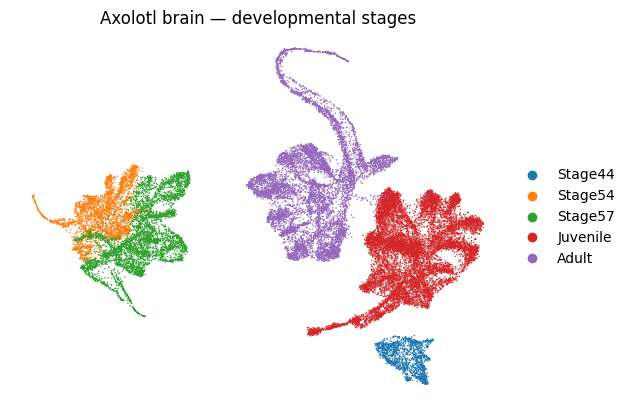

In [230]:
sc.pl.umap(
    adata,
    color="day",
    title="Axolotl brain — developmental stages",
    frameon=False,
)

## 2. Build State-Context Representation

CTF-C requires three per-cell representations:

- **PCA** (`X_pca`, 50-dim): transcriptomic representation — used as the velocity field input and the base OT cost.
- **SS context** (`local_mean_X_pca`, 50-dim): mean PCA embedding of each cell's spatial neighbours within radius 50. Encodes the local tissue niche.
- **LR features** (`LR_pattern`, 233-dim): ligand-receptor co-expression features from LIANA, aggregated over the spatial neighbourhood. Encodes local cell-cell communication context.

All three are already in the preprocessed adata. We concatenate them into a single 333-dim vector `X_state_ctx` and store it in `.obsm`. The custom coupling function will receive mini-batches of these vectors and splits them internally:

    source_lin[:, :N_PCA]            →  PCA         (50-dim)
    source_lin[:, N_PCA:N_PCA+N_SS]  →  SS context  (50-dim)
    source_lin[:, N_PCA+N_SS:]       →  LR features (233-dim)

The velocity field trains in 50-dim PCA space (`sample_rep='X_pca'`); only the coupling function sees the full 333-dim vector.

In [231]:
X_pca = adata.obsm["X_pca"].astype(np.float32)
ss_context = adata.obsm["local_mean_X_pca"].astype(np.float32)
lr_pattern = adata.obsm["LR_pattern"].astype(np.float32)

adata.obsm["X_state_ctx"] = np.concatenate([X_pca, ss_context, lr_pattern], axis=1)
print(f"X_pca shape:        {X_pca.shape}")
print(f"ss_context shape:   {ss_context.shape}")
print(f"lr_pattern shape:   {lr_pattern.shape}")
print(f"X_state_ctx shape:  {adata.obsm['X_state_ctx'].shape}")

X_pca shape:        (28757, 50)
ss_context shape:   (28757, 50)
lr_pattern shape:   (28757, 233)
X_state_ctx shape:  (28757, 333)


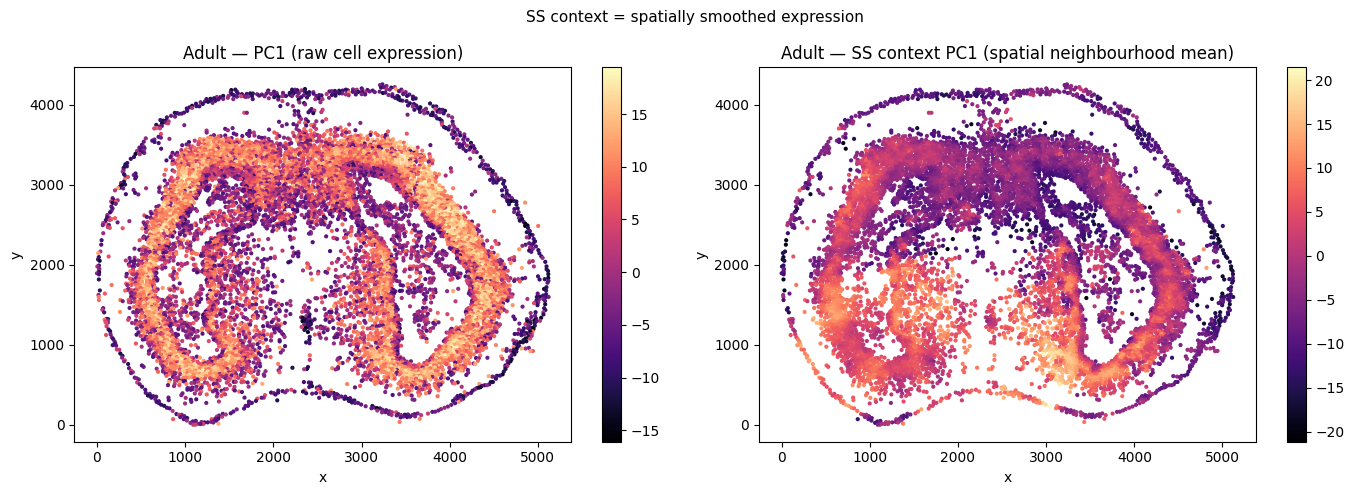

In [232]:
# Visualise SS context for the Adult stage
adult_mask = adata.obs["day"].values == "Adult"
coords = adata.obsm["spatial"][adult_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc_img = axes[0].scatter(coords[:, 0], coords[:, 1], c=X_pca[adult_mask, 0], s=4, cmap="magma")
plt.colorbar(sc_img, ax=axes[0])
axes[0].set_title("Adult — PC1 (raw cell expression)")

ss_img = axes[1].scatter(coords[:, 0], coords[:, 1], c=ss_context[adult_mask, 0], s=4, cmap="magma")
plt.colorbar(ss_img, ax=axes[1])
axes[1].set_title("Adult — SS context PC1 (spatial neighbourhood mean)")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("SS context = spatially smoothed expression", fontsize=11)
plt.tight_layout()
plt.show()

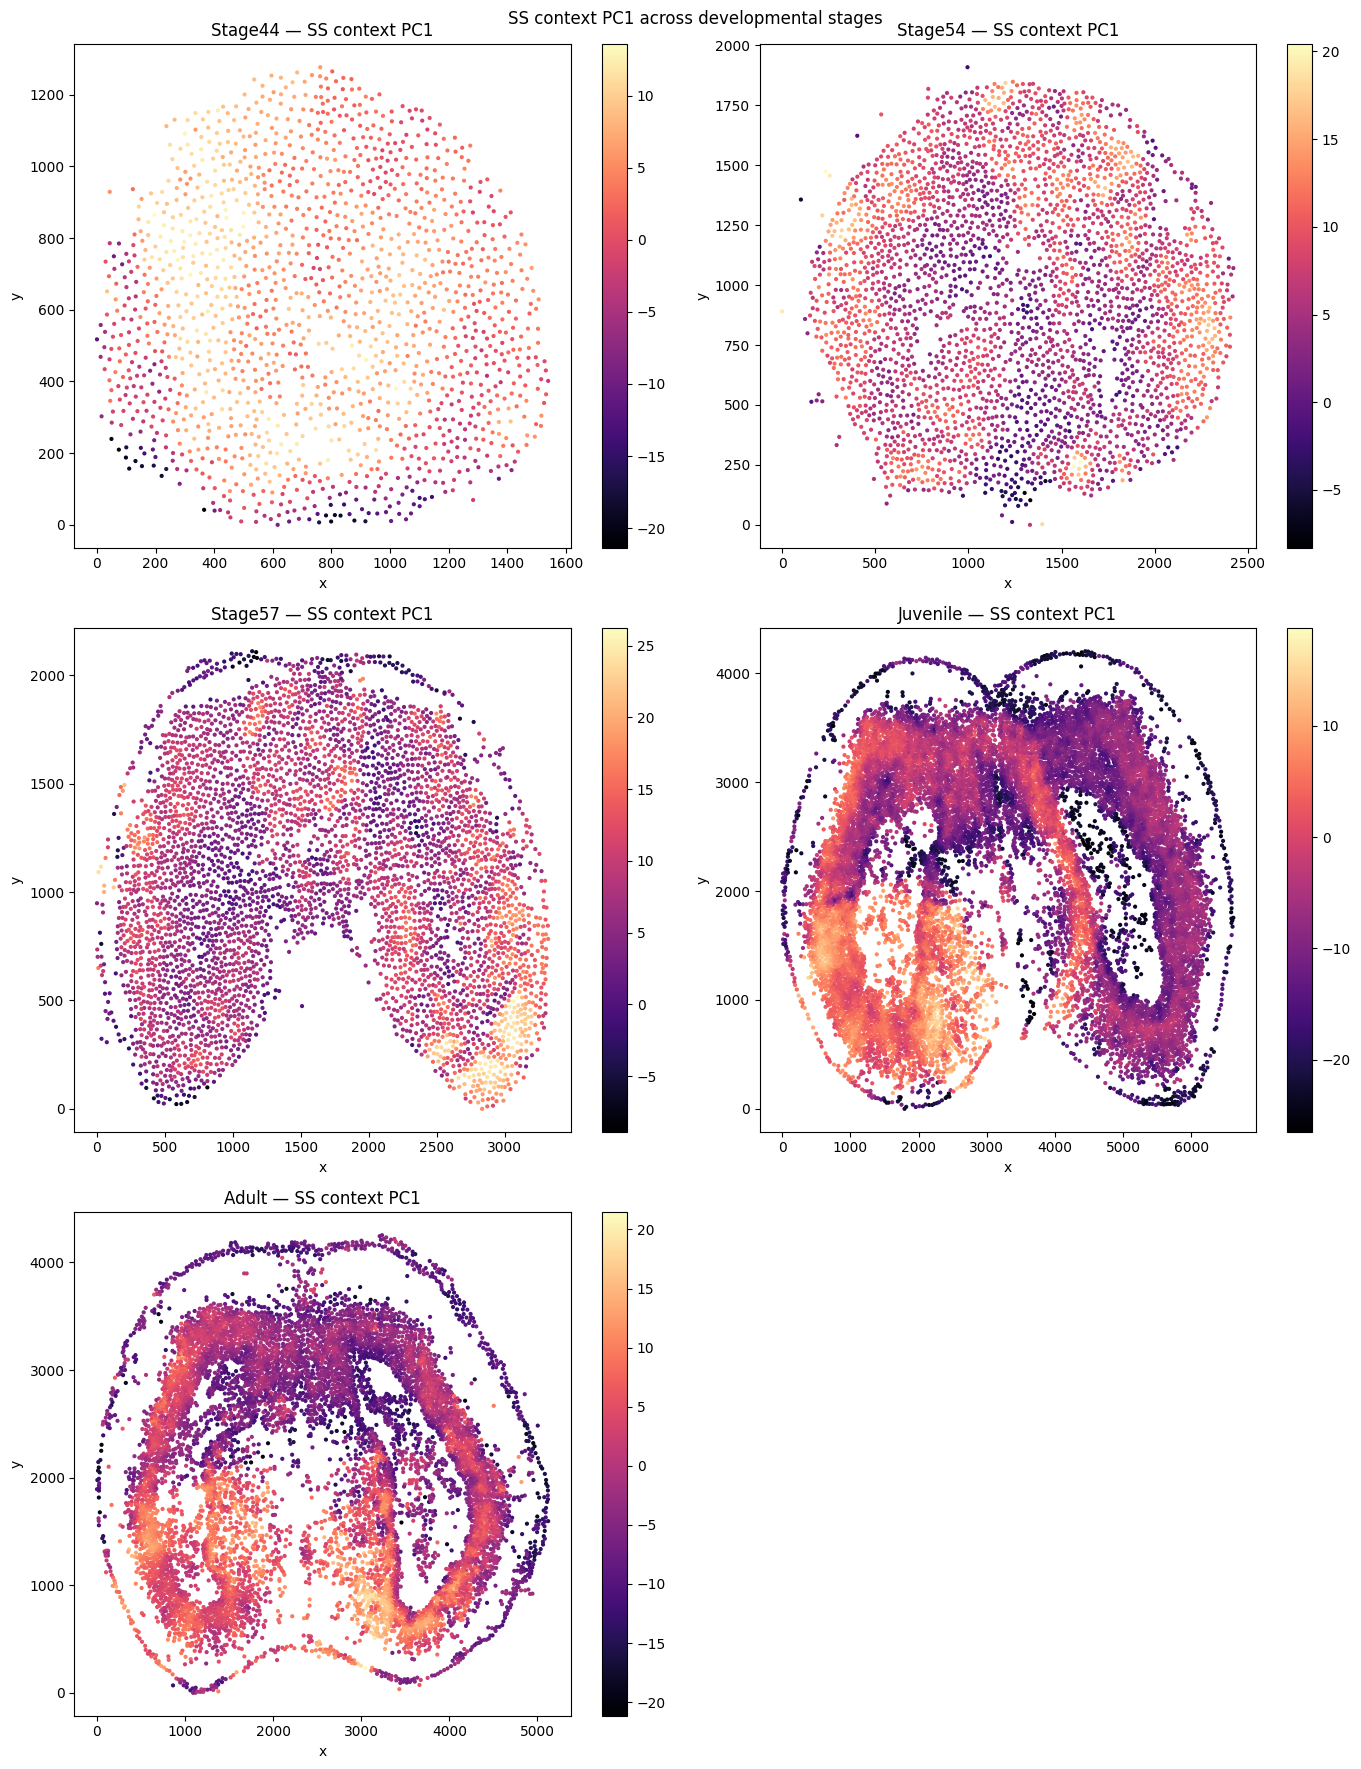

In [233]:
all_stages = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes_flat = axes.flatten()

for ax, stage in zip(axes_flat, all_stages, strict=False):
    mask = adata.obs["day"].values == stage
    coords = adata.obsm["spatial"][mask]
    ss_img = ax.scatter(coords[:, 0], coords[:, 1], c=ss_context[mask, 0], s=4, cmap="magma")
    plt.colorbar(ss_img, ax=ax)
    ax.set_title(f"{stage} — SS context PC1")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

axes_flat[-1].set_visible(False)
plt.suptitle("SS context PC1 across developmental stages", fontsize=12)

plt.tight_layout()
plt.show()

In the left plot, each point is colored by its 1st principal component. The pattern is noisy & granular. In the right plot, each point is colored by the mean PC1 of its spatial neighbors. The pattern is smoother, with regions of similar color. The __`SS`__ captures how the local tissue looks like instead of individual cells.

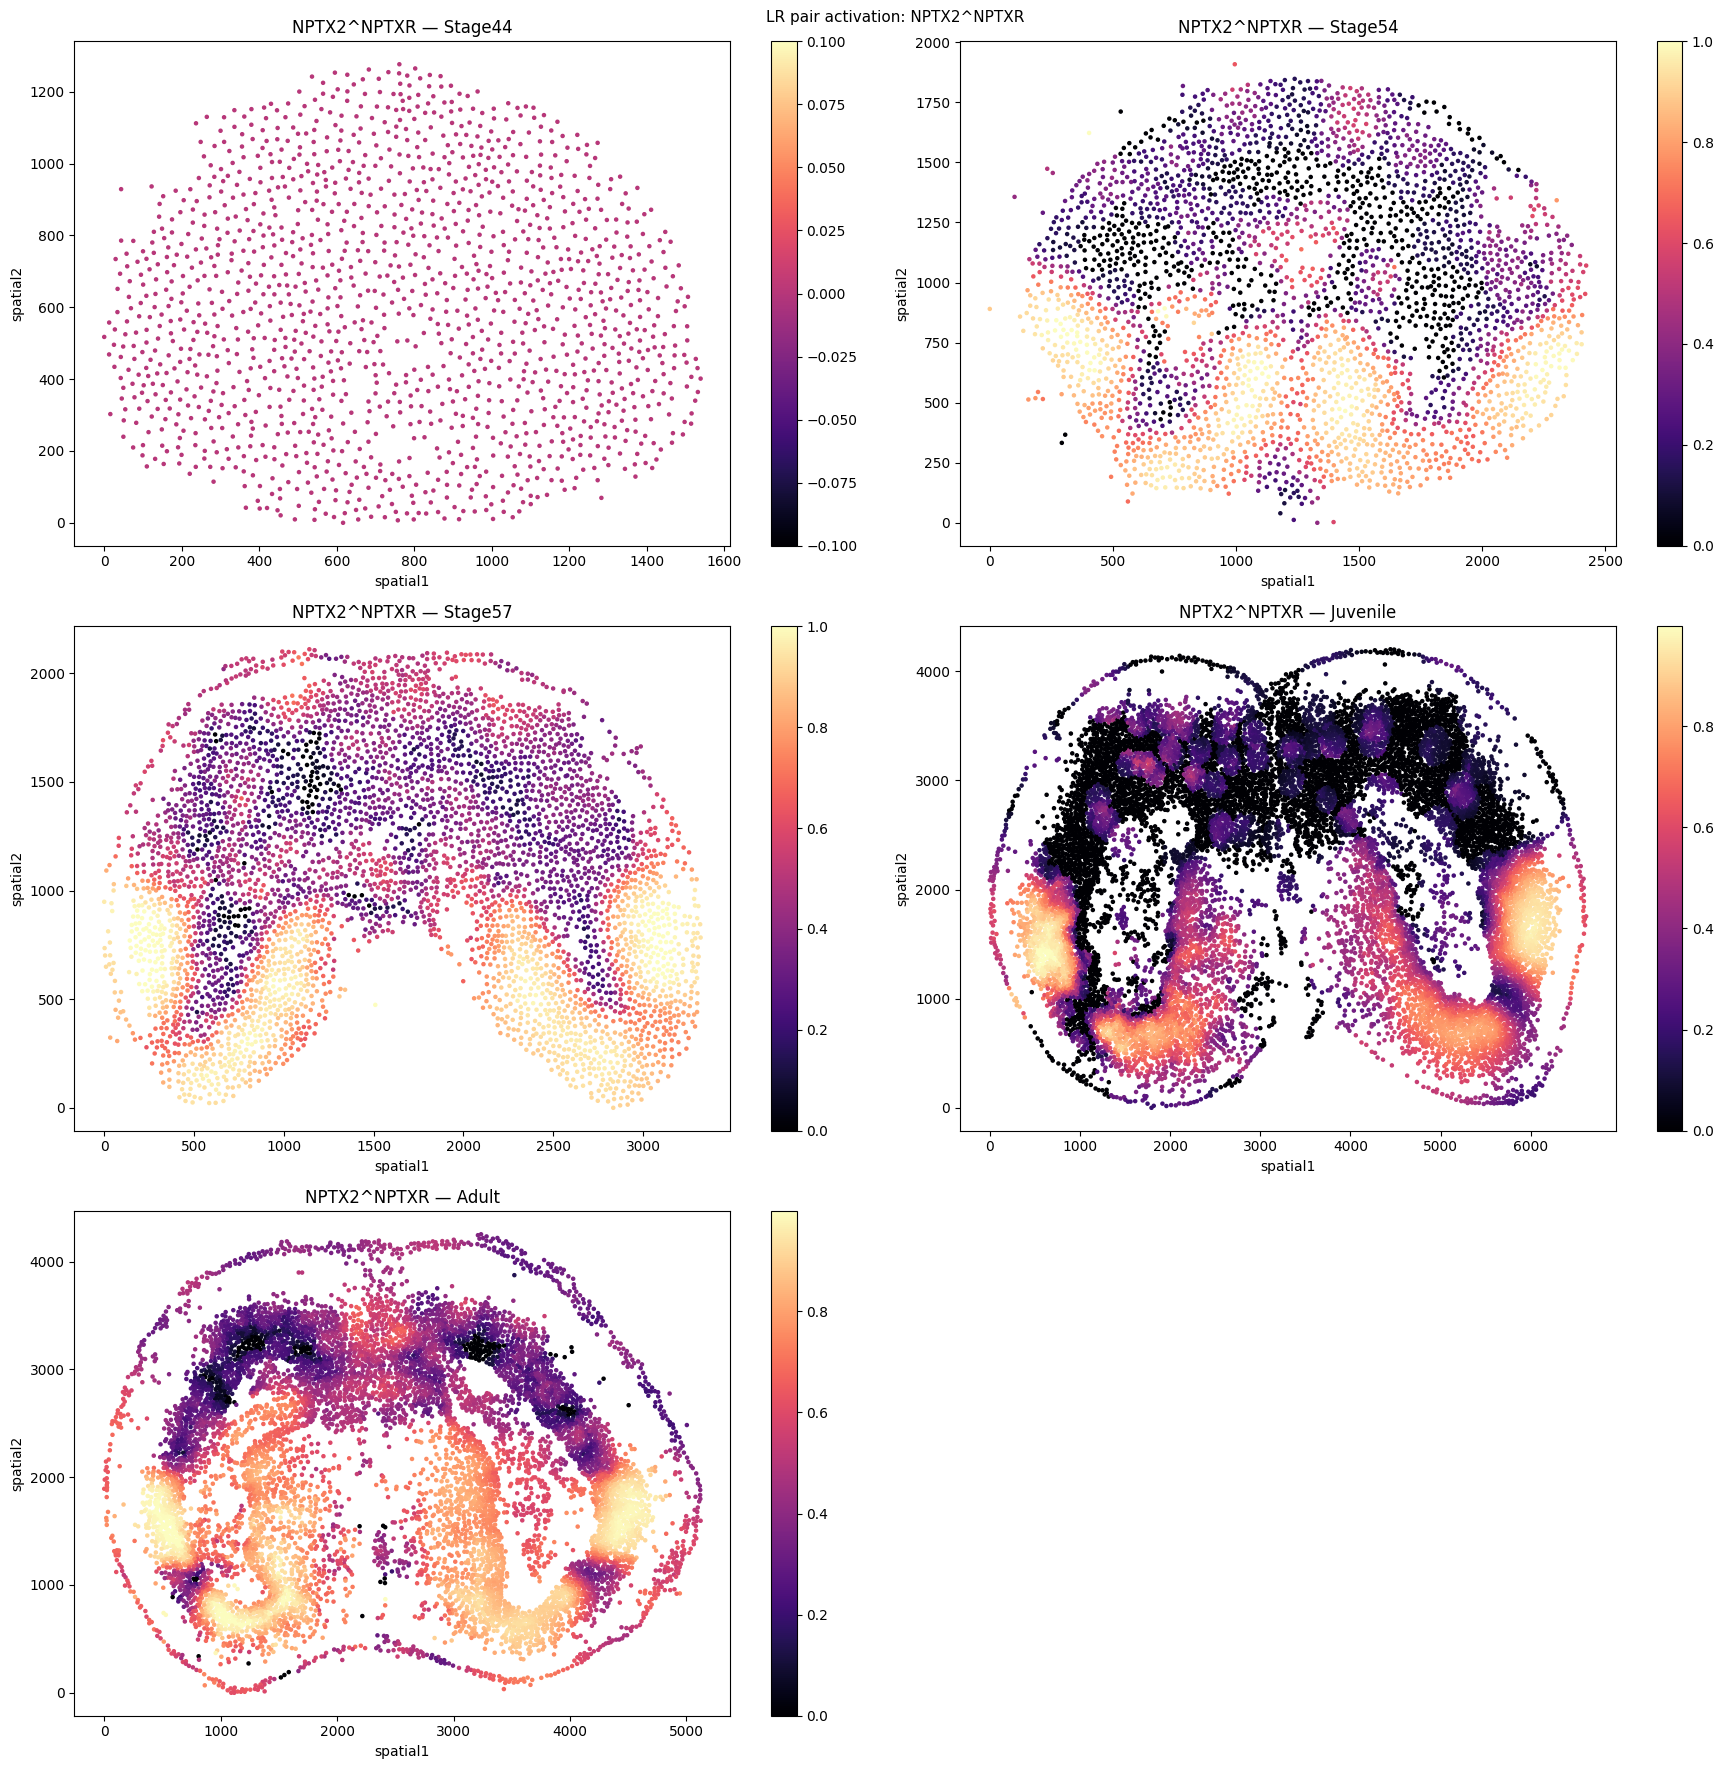

In [234]:
pair_name = "NPTX2^NPTXR"
pair_names = adata.uns["LR_pattern_pairs"]
pair_idx = np.where(pair_names == pair_name)[0][0]

all_stages = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]

all_activations = np.concatenate([adata.obsm["LR_pattern"][adata.obs["day"].values == s, pair_idx] for s in all_stages])

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes_flat = axes.flatten()

for ax, stage in zip(axes_flat, all_stages, strict=False):
    mask = adata.obs["day"].values == stage
    coords = adata.obsm["spatial"][mask]
    activation = adata.obsm["LR_pattern"][mask, pair_idx]
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=activation, s=5, cmap="magma")
    plt.colorbar(sc, ax=ax)
    ax.set_title(f"{pair_name} — {stage}")
    ax.set_xlabel("spatial1")
    ax.set_ylabel("spatial2")

axes_flat[-1].set_visible(False)  # hide the empty 6th cell
plt.suptitle(f"LR pair activation: {pair_name}", fontsize=11)
plt.tight_layout()
plt.show()

These plots show the activation of `NPTX2 -> NPTXR` ligand-receptor pair activation across the stages. In __stage44__, we observe that the activation is almost zero everywhere which would indicate that this LR pair is not active in this developmental stage whereas there is different levels of activation across the tissue in __stage54__. Throughtout the next stages, this activation is maximum in the southern cornes of the sace. The idea here is that a cell in stage44 which shows no activation of this LR pair should not be coupled with a cell in a high activation zone in stage54 because it is very unlikely to see a sudden change in LR activation.

## 3. Custom CTF-C Coupling Function

Coupling defines which cell from the source distribution gets paired with which cell from the target distribution. There are multiple types of coupling options such as `Independent coupling` where the pairing is done randomly, `OT coupling` where the pairing is chosen such that the transort cost of `source -> target` is minimized etc.

CTF-C modifies the traditional `OT coupling` by adding spatial priors into the OT cost matrix. The two spatial dissimilarity terms are blended into a **Transitional Plausibility Matrix (TPM)**:

$$M_{k,l} = \lambda \|ss_k - ss_l\|^2 + (1 - \lambda) \|lr_k - lr_l\|^2$$

High $M_{k,l}$ means the transition from cell $k$ to cell $l$ is spatially implausible. This is then blended with the transcriptomic cost:

$$C_{k,l} = \alpha \|x_k - x_l\|^2 + (1 - \alpha) \, M_{k,l}$$

- $\alpha \in [0,1]$ — blend between transcriptomic cost and spatial prior ($\alpha=1$: pure transcriptomic OT, $\alpha=0$: pure spatial prior)
- $\lambda \in [0,1]$ — blend between SS and LR within the TPM ($\lambda=1$: pure SS, $\lambda=0$: pure LR)

Standard entropic OT (Sinkhorn) is solved on this combined $C$ — nothing else changes in the solver.

`coupling_rep='X_state_ctx'` ensures the coupling function receives the full 333-dim vector (PCA + SS + LR) for each mini-batch. The function splits it internally to access each component.

In [ ]:
def ctf_c_coupling(source_lin, target_lin, CTF_LAMBDA, CTF_ALPHA, N_PCA, N_SS, scale_method, reg, **kwargs):
    """CTF-C: ot_linear_coupling with spatially-biased cost (SS + LR TPM)."""
    src_pca = source_lin[:, :N_PCA]
    src_ss = source_lin[:, N_PCA : N_PCA + N_SS]
    src_lr = source_lin[:, N_PCA + N_SS :]

    tgt_pca = target_lin[:, :N_PCA]
    tgt_ss = target_lin[:, N_PCA : N_PCA + N_SS]
    tgt_lr = target_lin[:, N_PCA + N_SS :]

    def cost_fn(src, tgt):
        """Build spatially-blended OT cost from PCA, SS, and LR distances."""
        C_pca = torch.cdist(src, tgt) ** 2
        C_pca = C_pca / C_pca.max()

        SS = torch.cdist(src_ss, tgt_ss) ** 2
        SS = SS / SS.max()

        LR = torch.cdist(src_lr, tgt_lr) ** 2
        LR = LR / LR.max()

        M = CTF_ALPHA * SS + (1 - CTF_ALPHA) * LR
        cost = CTF_LAMBDA * C_pca + (1 - CTF_LAMBDA) * M
        return cost

    result = ot_linear_coupling(src_pca, tgt_pca, cost_fn=cost_fn, scale_cost=scale_method, reg=reg)

    return result

### Alternative: Custom `cost_fn`

The `ctf_c_coupling` above is a custom coupling function that we can use in our model. But if you thought that all of logic could have been written as a custom cost function and nothing would have been changed, you would be correct. You are free to create your own custom cost function and the model will handle everything ese internally. In this scenario, both produce equivalent cost matrices so you have the freedom to do whatever fits your experiment best.


```python
import functools

def ctf_c_cost_fn(src, tgt, alpha=0.8, lam=0.5):
    src_pca, tgt_pca = src[:, :N_PCA], tgt[:, :N_PCA]
    src_ss,  tgt_ss  = src[:, N_PCA:N_PCA+N_SS], tgt[:, N_PCA:N_PCA+N_SS]
    src_lr,  tgt_lr  = src[:, N_PCA+N_SS:], tgt[:, N_PCA+N_SS:]
    C_pca = torch.cdist(src_pca, tgt_pca) ** 2
    M = lam * torch.cdist(src_ss, tgt_ss)**2 + (1-lam) * torch.cdist(src_lr, tgt_lr)**2
    return alpha * C_pca + (1-alpha) * M

match_fn = functools.partial(ot_linear_coupling,
                                cost_fn=functools.partial(ctf_c_cost_fn,
                                alpha=CTF_ALPHA,
                                lam=CTF_LAMBDA))

model = SCFlow(method_id="cfm",
                backend="torch",
                match_fn=match_fn, ...)
```

Both produce equivalent cost matrices so you have the freedom to do whatever fits your experiment best.

## 4. Multi-TimePoint Flow Matching: Interpolation

Before training the model, we must first understand what it is that we are doing and what is `Multi-TimePoint Flow Matching`. In a standard flow matching training, we have a `Source` and a `Target`, and we train model to create the `velocity field` between these two distributions across $n$ time points where at $t= 0$, we have the `Source` distribution and at $t= 1$, we have the `Target` distribution. When training, we take a random time-point between 0 & 1, predict the velocity and dirction of the distribution.

In Multi-TimePoint Flow Matching, we consider each of the stages as intermediate timepoints. So we can imagine that at $t=0$ we have the `Stage44` distribution. At $t=0.2$ we have the `Stage54` distribution, `Stage57` at $t=0.4$ and so on and they have a shared velocity field. When training, we take a batch from each of these pairs and the veloctiy field is trained.

Now coming to `Interpolation`. This is one of the 2 evaluation methods used by the authors. Here, the model is trained on all the time points except for `juvenile`.
* Stage44 -> Stage54
* Stage54 -> Stage57
* Stage57 -> Adult

As you can see, we skip the `juvenile` timepoint and pair `stage57` directly with `Adult`. The logic is that since `juvenile` is in between these 2 stages, how well can the model predict this stage?

### 4.1 Data Registration

In [ ]:
ALPHA = 0.5
LAMBDA = 0.4
hidden_dims = (10, 10, 10)
activation = torch.nn.SELU
epoch = 10_000
lr = 1e-4
batch_size = 256
probability_path = LinearGaussianProbabilityPath(sigma=0.9, prng=prng)
scale_method = 1.0  # Cost matrix is not scaled in ContextFlow
reg = 0.1
N_EVAL = 1500
solver = "dopri5"
debug_intra = "debug_intra2"

matched_keys = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Adult",),
}

transitions = {
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
}

t_start_train = [0, 1, 2, 4]

t_start_pred = [0, 1, 2, 3]
t_end_pred = [1, 2, 3, 4]

Stage embeddings: {'Stage44': 0.0, 'Stage54': 0.25, 'Stage57': 0.5, 'Juvenile': 0.75, 'Adult': 1.0}


Before we initiate our model, we must first register our data. Imagine giving a blueprint of your dataset which tells it what are the conditions to look at, what are the dimensions etc. to the model. Now the model will always expect to be given data which fits this blueprint.

In [ ]:
SCFlow.register_adata(
    adata,
    sample_rep="X_pca",
    coupling_rep="X_state_ctx",
    conditions={"day": ["day"]},
    conditions_reps={"day": "stage_emb"},
    matched_keys=matched_keys,
)

### 4.2 Model Setup & Train

In [ ]:
ctf_c_partial = functools.partial(
    ctf_c_coupling,
    CTF_LAMBDA=LAMBDA,
    CTF_ALPHA=ALPHA,
    N_PCA=50,
    N_SS=50,
    scale_method=scale_method,
    reg=reg,
)

In [ ]:
model_intra = SCFlow(
    method_id="cfm",
    backend="torch",
    match_fn=ctf_c_partial,
    vf_decoder_mlp_kwargs={"hidden_dims": hidden_dims, "activation_cls": activation},
)

is_paired_setting: True


In [ ]:
model_intra.train(
    adata,
    callbacks=None,
    sort=True,
    n_train_steps=epoch,
    train_batch_size=batch_size,
    train_sampler=MultiTransitionSampler,
    optim_kwargs={"lr": lr},
    timepoints=[0, 1, 2, 3],
    probability_path=probability_path,
)

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|██████████| 3/3 [00:00<00:00, 273.21it/s]
| loss:4.6718 | step:9999: 100%|██████████| 10000/10000 [04:57<00:00, 33.62it/s]


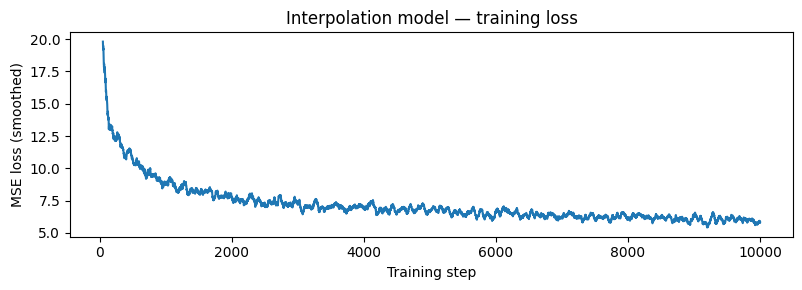

In [ ]:
logs_inter = model_intra.trainer.get_train_logs_df()
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(logs_inter["loss"].rolling(50).mean(), lw=1.5)
ax.set_xlabel("Training step")
ax.set_ylabel("MSE loss (smoothed)")
ax.set_title("Interpolation model — training loss")
plt.tight_layout()
plt.show()

## 5. Multi Timepoint Flow Matching: Extrapolation

`Extrapolation`. is the other of the 2 evaluation methods used by the authors. Here, the model is trained on all the time points except for `adult`.
* Stage44 -> Stage54
* Stage54 -> Stage57
* Stage57 -> Juvenile

The logic is that the `adult` timepoint is completely out of the timepoints used in training. So how well can the model extrapolate from what its learned and predict?

### 5.1 Data Registration

In [ ]:
ALPHA = 0.5
LAMBDA = 0.4
hidden_dims = (10, 10, 10)
activation = torch.nn.SELU
epoch = 10_000
lr = 1e-4
batch_size = 256
probability_path = LinearGaussianProbabilityPath(sigma=0.9, prng=prng)
scale_method = 1.0  # Cost matrix is not scaled in ContextFlow
reg = 0.1
N_EVAL = 1500
solver = "dopri5"
debug_extra = "debug_extra2"

matched_keys_extra = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Juvenile",),
}

transitions = {
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
}

t_start_train = [0, 1, 2, 3]

t_start_pred = [0, 1, 2, 3]
t_end_pred = [1, 2, 3, 4]

Stage embeddings: {'Stage44': 0.0, 'Stage54': 0.25, 'Stage57': 0.5, 'Juvenile': 0.75, 'Adult': 1.0}


In [245]:
SCFlow.register_adata(
    adata,
    sample_rep="X_pca",
    coupling_rep="X_state_ctx",
    conditions={"day": ["day"]},
    conditions_reps={"day": "stage_emb"},
    matched_keys=matched_keys_extra,
)

### 5.2 Model Setup & Training

In [246]:
model_extra = SCFlow(
    method_id="cfm",
    backend="torch",
    match_fn=ctf_c_partial,
    vf_decoder_mlp_kwargs={"hidden_dims": (100, 100, 100, 100)},
)

print("is_paired_setting:", model_extra.is_paired_setting)

is_paired_setting: True


In [247]:
model_extra.train(
    adata,
    callbacks=None,
    sort=True,
    n_train_steps=10_000,
    train_batch_size=256,
    optim_kwargs={"lr": 5e-4},
)

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|██████████| 3/3 [00:00<00:00, 422.22it/s]
| loss:4.8392 | step:9999: 100%|██████████| 10000/10000 [06:51<00:00, 24.32it/s]


In [ ]:
logs_extra = model_extra.trainer.get_train_logs_df()
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(logs_extra["loss"].rolling(50).mean(), lw=1.5)
ax.set_xlabel("Training step")
ax.set_ylabel("MSE loss (smoothed)")
ax.set_title("Extrapolation model — training loss")
plt.tight_layout()
plt.show()

## 6. Inference & Evaluation

In [ ]:
def plot_transition(ax, adata, src_stage, tgt_stage, X_pred, title=None):
    """Scatter source, predicted, and true target cells in PCA space."""
    X_pca_all = adata.obsm["X_pca"]
    src_mask = adata.obs["day"].values == src_stage
    tgt_mask = adata.obs["day"].values == tgt_stage

    ax.scatter(X_pca_all[src_mask, 0], X_pca_all[src_mask, 1], s=2, alpha=0.15, color="steelblue", label=src_stage)
    ax.scatter(X_pred[:, 0], X_pred[:, 1], s=5, alpha=0.7, color="tomato", label="Predicted")
    ax.scatter(X_pca_all[tgt_mask, 0], X_pca_all[tgt_mask, 1], s=5, alpha=0.5, color="seagreen", label=tgt_stage)
    ax.set_title(title or f"{src_stage} → {tgt_stage}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.tick_params(left=False, bottom=False)
    ax.legend(loc="upper right", markerscale=2, frameon=False)

In [ ]:
def plot_pcas(ax, adata, src_stage, tgt_stage, title=None):
    """Scatter source and true target cells in PCA space without predictions."""
    X_pca_all = adata.obsm["X_pca"]
    src_mask = adata.obs["day"].values == src_stage
    tgt_mask = adata.obs["day"].values == tgt_stage

    ax.scatter(X_pca_all[src_mask, 0], X_pca_all[src_mask, 1], s=2, alpha=1, color="steelblue", label=src_stage)
    ax.scatter(X_pca_all[tgt_mask, 0], X_pca_all[tgt_mask, 1], s=5, alpha=0.5, color="seagreen", label=tgt_stage)
    ax.set_title(title or f"{src_stage} → {tgt_stage}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.tick_params(left=False, bottom=False)
    ax.legend(loc="upper right", markerscale=2, frameon=False)

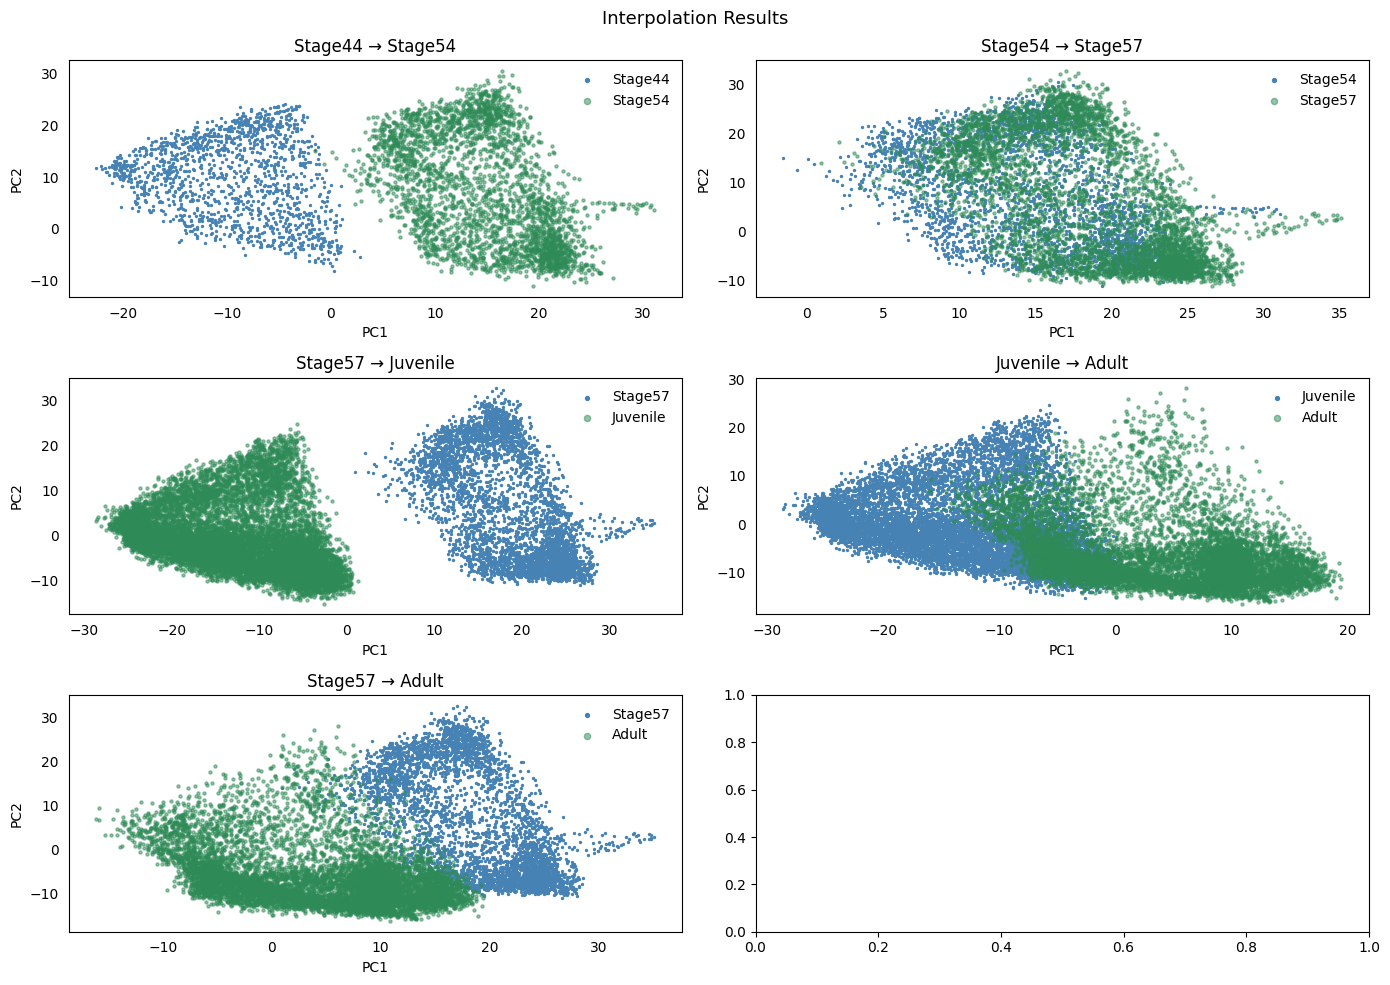

In [251]:
transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
    ("Stage57", "Adult"),  # direct transition skipping Juvenile
]


fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, (src, tgt) in zip(axes.flat, transitions, strict=False):
    plot_pcas(ax, adata, src, tgt)

plt.suptitle("Interpolation Results", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
    ("Stage57", "Adult"),  # direct transition skipping Juvenile
]

preds_inter = {}
for src, tgt in transitions:
    result = model_intra.predict(
        adata,
        sort=True,
        matched_keys={(src,): (tgt,)},
        return_trajectory=True,
        num_steps=400,
    )
    preds_inter[(src, tgt)] = np.array(result.X)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, (src, tgt) in zip(axes.flat, transitions, strict=False):
    plot_transition(ax, adata, src, tgt, preds_inter[(src, tgt)])

plt.suptitle("Interpolation Results", fontsize=13)
plt.tight_layout()
plt.show()

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Predicting: 100%|██████████| 1/1 [00:02<00:00,  2.84s/it]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Predicting: 100%|██████████| 1/1 [00:04<00:00,  4.28s/it]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str

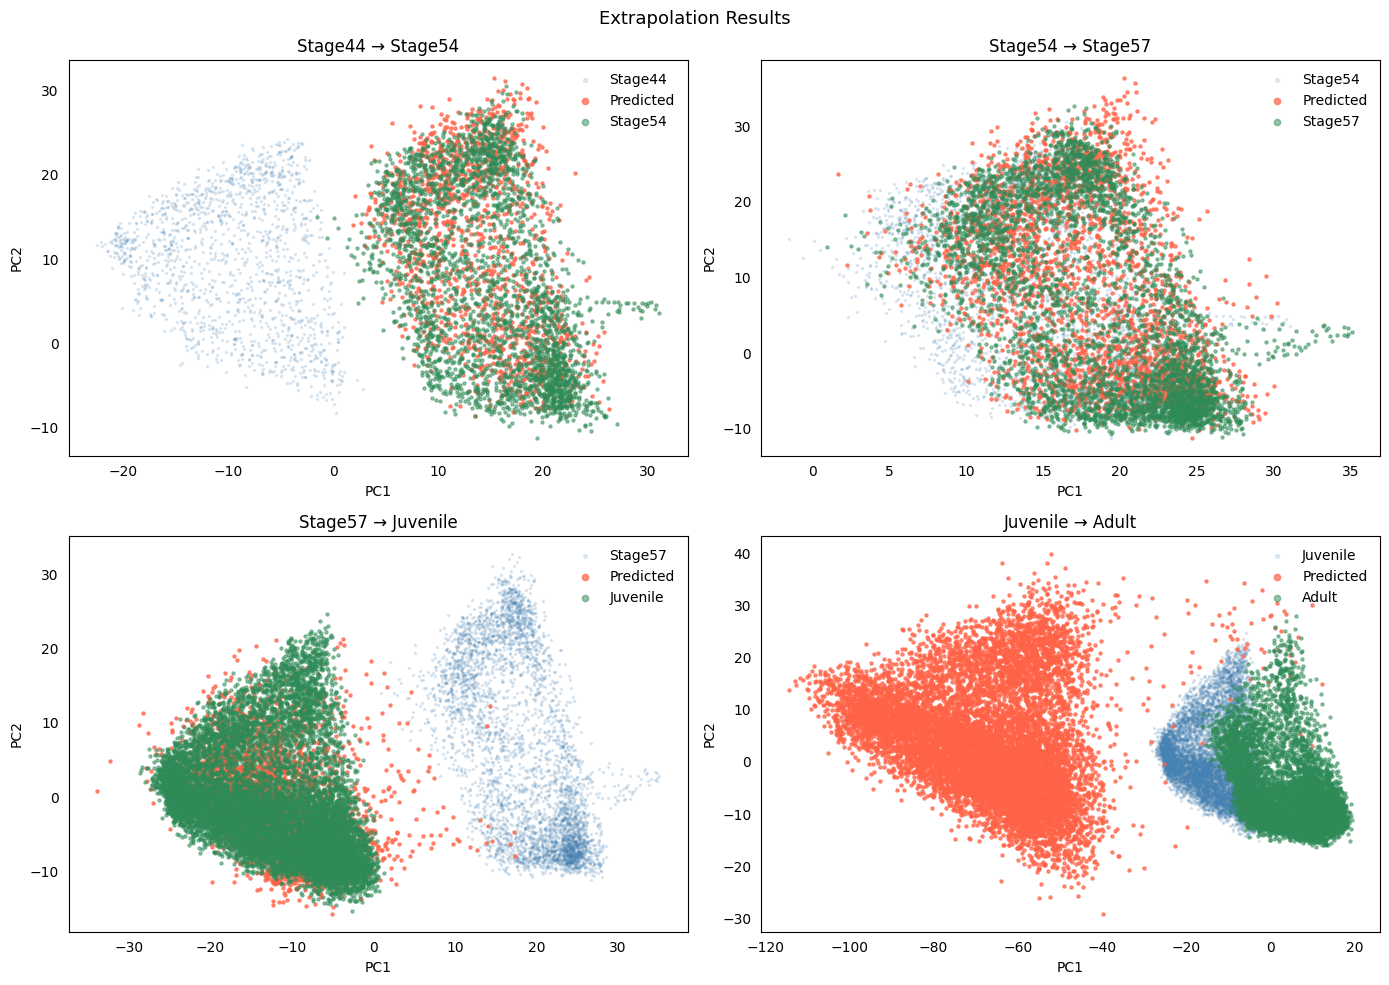

In [253]:
transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
]

preds_extra = {}
for src, tgt in transitions:
    result = model_extra.predict(
        adata,
        sort=True,
        matched_keys={(src,): (tgt,)},
        return_trajectory=True,
        num_steps=400,
    )
    preds_extra[(src, tgt)] = np.array(result.X)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (src, tgt) in zip(axes.flat, transitions, strict=False):
    plot_transition(ax, adata, src, tgt, preds_extra[(src, tgt)])

plt.suptitle("Extrapolation Results", fontsize=13)
plt.tight_layout()
plt.show()

In [254]:
N_EVAL = 500


def compute_w2(X, Y):
    """2-Wasserstein distance (exact EMD, subsampled to N_EVAL)."""
    rng = np.random.RandomState(SEED)
    Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)].astype(np.float64)
    Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)].astype(np.float64)
    a, b = pot.unif(Xi.shape[0]), pot.unif(Yi.shape[0])
    M = torch.cdist(torch.tensor(Xi).float(), torch.tensor(Yi).float()).numpy().astype(np.float64) ** 2
    return float(np.sqrt(pot.emd2(a, b, M)))


def compute_mmd(X, Y):
    """Multi-gamma MMD (sc_flow MaximumMeanDiscrepancy, gammas=[2,1,0.5,0.1,0.01,0.005])."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = MaximumMeanDiscrepancy()
    m.update(Xi, Yi)
    return float(m.compute())


def compute_energy(X, Y):
    """Energy distance (sc_flow EnergyDistance)."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = EnergyDistance()
    m.update(Xi, Yi)
    return float(m.compute())

In [ ]:
transitions_eval = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
]


def build_metrics_rows(preds_dict, method_name):
    """Compute W2/MMD/Energy for predicted and baseline vs true target, for all transitions."""
    rows = []
    for src, tgt in transitions_eval:
        X_pred = preds_dict[(src, tgt)]
        X_src = adata[adata.obs["day"] == src].obsm["X_pca"].astype(np.float32)
        X_tgt = adata[adata.obs["day"] == tgt].obsm["X_pca"].astype(np.float32)
        label = f"{src.replace('Stage', 'S')}→{tgt.replace('Stage', 'S')}"
        rows.append(
            {
                "transition": label,
                "method": "Baseline",
                "W2": compute_w2(X_src, X_tgt),
                "MMD": compute_mmd(X_src, X_tgt),
                "Energy": compute_energy(X_src, X_tgt),
            }
        )
        rows.append(
            {
                "transition": label,
                "method": method_name,
                "W2": compute_w2(X_pred, X_tgt),
                "MMD": compute_mmd(X_pred, X_tgt),
                "Energy": compute_energy(X_pred, X_tgt),
            }
        )
    return rows


df_inter = pd.DataFrame(build_metrics_rows(preds_inter, "CTF-C"))
df_extra = pd.DataFrame(build_metrics_rows(preds_extra, "CTF-C"))

print("=== Interpolation model ===")
print(df_inter.pivot(index="transition", columns="method", values=["W2", "MMD", "Energy"]).round(4).to_string())
print()
print("=== Extrapolation model ===")
print(df_extra.pivot(index="transition", columns="method", values=["W2", "MMD", "Energy"]).round(4).to_string())

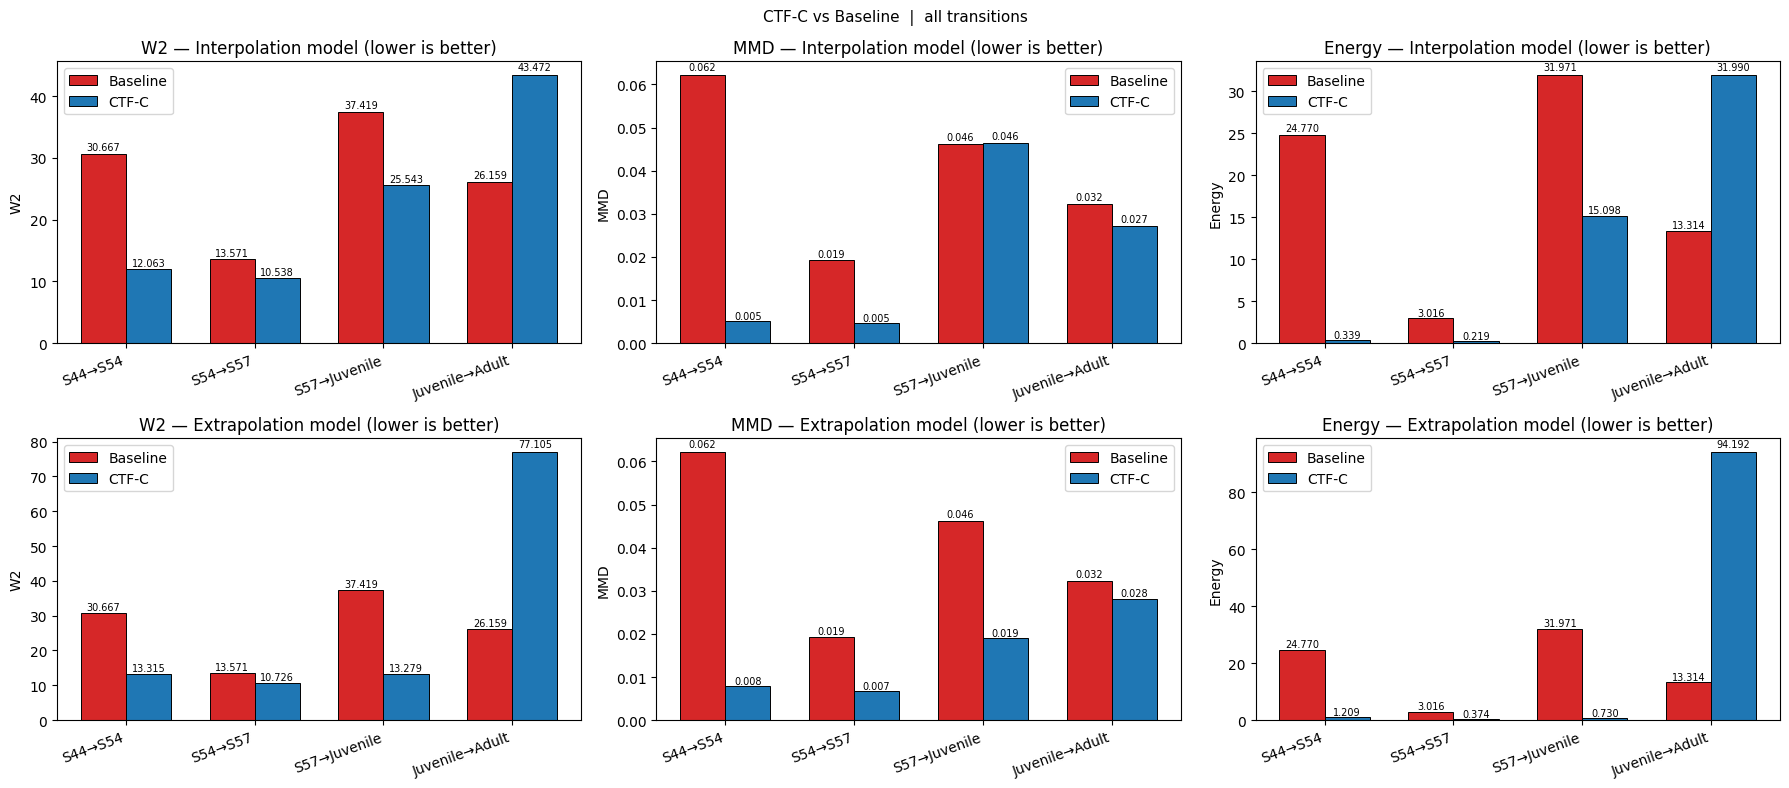

In [256]:
metric_names = ["W2", "MMD", "Energy"]
t_labels = [f"{s.replace('Stage', 'S')}→{t.replace('Stage', 'S')}" for s, t in transitions_eval]
methods = ["Baseline", "CTF-C"]
colors = {"Baseline": "#d62728", "CTF-C": "#1f77b4"}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
x = np.arange(len(t_labels))
w = 0.35

for row_idx, (df, model_label) in enumerate([(df_inter, "Interpolation model"), (df_extra, "Extrapolation model")]):
    for col_idx, mname in enumerate(metric_names):
        ax = axes[row_idx, col_idx]
        for i, method in enumerate(methods):
            vals = [df[(df["transition"] == t) & (df["method"] == method)][mname].values[0] for t in t_labels]
            bars = ax.bar(
                x + (i - 0.5) * w, vals, w, label=method, color=colors[method], edgecolor="black", linewidth=0.7
            )
            for bar, v in zip(bars, vals, strict=False):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f"{v:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )
        ax.set_xticks(x)
        ax.set_xticklabels(t_labels, rotation=20, ha="right")
        ax.set_title(f"{mname} — {model_label} (lower is better)")
        ax.set_ylabel(mname)
        ax.legend()

plt.suptitle("CTF-C vs Baseline  |  all transitions", fontsize=11)
plt.tight_layout()
plt.show()